In [5]:
import os
import cv2
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

In [124]:
base_path = "preprocessing with dl"
ty = ["lr_.png", "wi.png", "rl.png", "bm.png", "hr.png"]
pp_fn = ['lr.png', 'base.png', 'w.png', 'rl.png', 'bm.png', 'hr.png']
hy_ff = ['lr.png', 'w.png', 'rl.png', 'hr.png']
titles = ['LR', 'Wiener', 'RL',  'BM3D', 'HR']
titles_dl = ['LR', 'Base', 'Wiener', 'RL',  'BM3D', 'HR']
titles_hy = ['LR', 'Wiener', 'RL', 'HR']
models = ["01 SRCNN", "02 EDSR", "03 CARN", "04 RDN","05 DRRN",
          "06 LapSRN", "07 RCAN",  "11 ESRGAN", "13 SRGAN", "finetuned_SRGAN"]

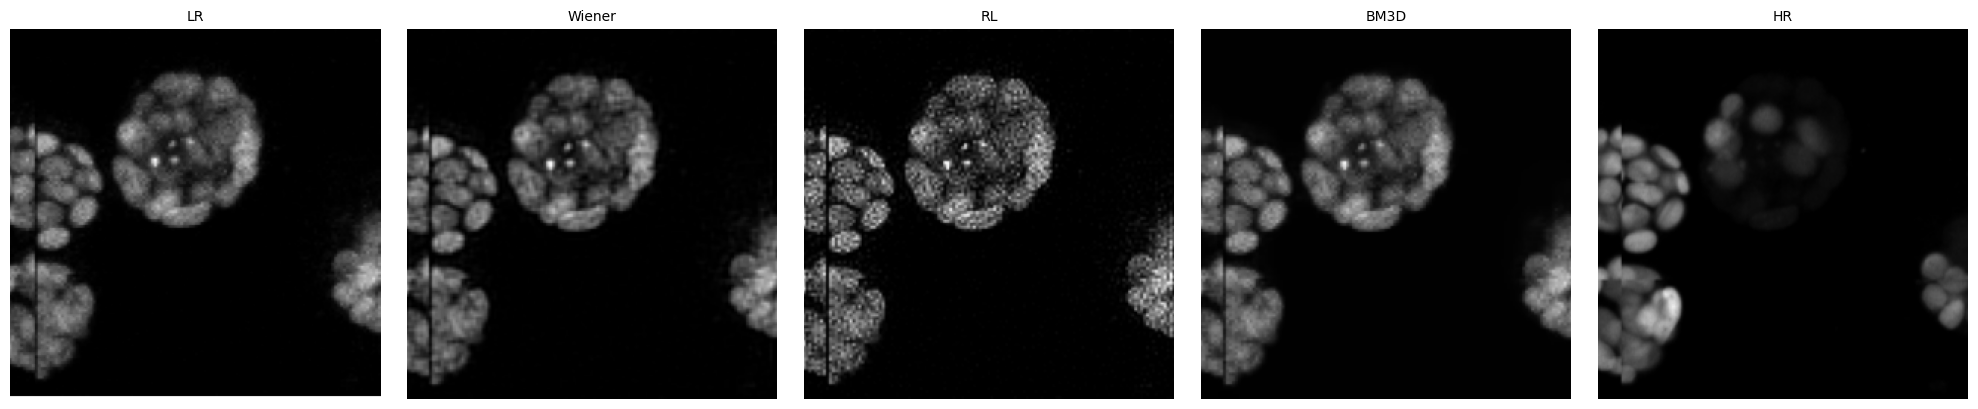

In [13]:
images = [Image.open(os.path.join(base_path, fname)) for fname in ty]

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, title in zip(axs, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("preprocessing_comparison_grid_x4.png", dpi=300)
plt.show()

In [111]:
# Test image selection
image_name = "image_3"

In [184]:
def calculate_psnr(img1, img2, max_value=255):
    """"Calculating peak signal-to-noise ratio (PSNR) between two images."""
    mse = np.mean((np.array(img1, dtype=np.float32) - np.array(img2, dtype=np.float32)) ** 2)
    if mse == 0:
        return 100
    return 20 * np.log10(max_value / (np.sqrt(mse)))

from skimage.metrics import structural_similarity as ssim_sk

def calculate_ssim(img1, img2):
    """"Calculating structural similarity index (SSIM) between two images."""
    # Convert images to grayscale
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    (ssim_skk, ssim_diff) = ssim_sk(img1_gray, img2_gray, data_range=img1_gray.max() - img2_gray.min(), full=True)
    return ssim_skk

In [128]:
def load_images(image_name, scale="x4"):
    hr_path = os.path.join(base_path, "HR", f"{image_name}.png")
    lr_path = os.path.join(base_path, "LR", scale, f"{image_name}.png")

    hr_img = cv2.imread(f"{hr_path}", cv2.IMREAD_COLOR)
    lr_img = cv2.imread(f"{lr_path}", cv2.IMREAD_COLOR)

    sr_imgs = []
    for model in models:
        sr_path = os.path.join(base_path, "SR",
                               model, scale, f"{image_name}.png")
        # print(sr_path)
        sr_img = cv2.imread(f"{sr_path}", cv2.IMREAD_COLOR)
        sr_imgs.append(sr_img)

    return hr_img, lr_img, sr_imgs

# Define region to zoom in (Modify x, y, w, h based on interest area)
def crop_zoomed_region(img, x, y, w, h, scale_factor=4):
    cropped = img[y:y+h, x:x+w]  # Crop selected area
    zoomed = cv2.resize(cropped, (w*scale_factor, h *
                        scale_factor), interpolation=cv2.INTER_CUBIC)
    return zoomed

def show_crop_area(img, x, y, w, h):
    img_copy = img.copy()
    # x, y, w, h = int(x), int(y), int(w), int(h)
    img_copy = cv2.rectangle(img_copy, (x, y), (x+h, y+w), (255, 0, 0), 2)  # Draw rectangle
    plt.title("Selected Crop Area")
    plt.axis("off")
    plt.imshow(img_copy)

In [185]:
# Load images
hr_img, lr_img, sr_imgs = load_images(image_name, scale="x4")

# Compute PSNR & SSIM for each SR image
psnr_values = [calculate_psnr(hr_img, sr) for sr in sr_imgs]
ssim_values = [calculate_ssim(hr_img, sr) for sr in sr_imgs]

In [116]:
for im in sr_imgs:
    print(im.shape)

(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)


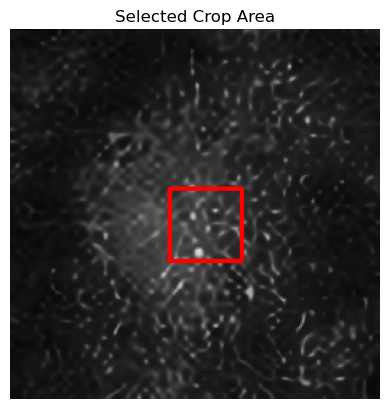

In [127]:
# Define zoomed-in region coordinates (modify as needed)
x, y, w, h = 110, 110, 50, 50  # ROI (Region of Interest)
show_crop_area(sr_imgs[2], x, y, w, h)

In [121]:
# Extract zoomed-in patches
zoomed_patches = [crop_zoomed_region(hr_img, x, y, w, h)]
zoomed_patches.append(crop_zoomed_region(
    lr_img, x//4, y//4, w//4, h//4))  # Adjust for LR scale

for sr_img in sr_imgs:
    zoomed_patches.append(crop_zoomed_region(sr_img, x, y, w, h))

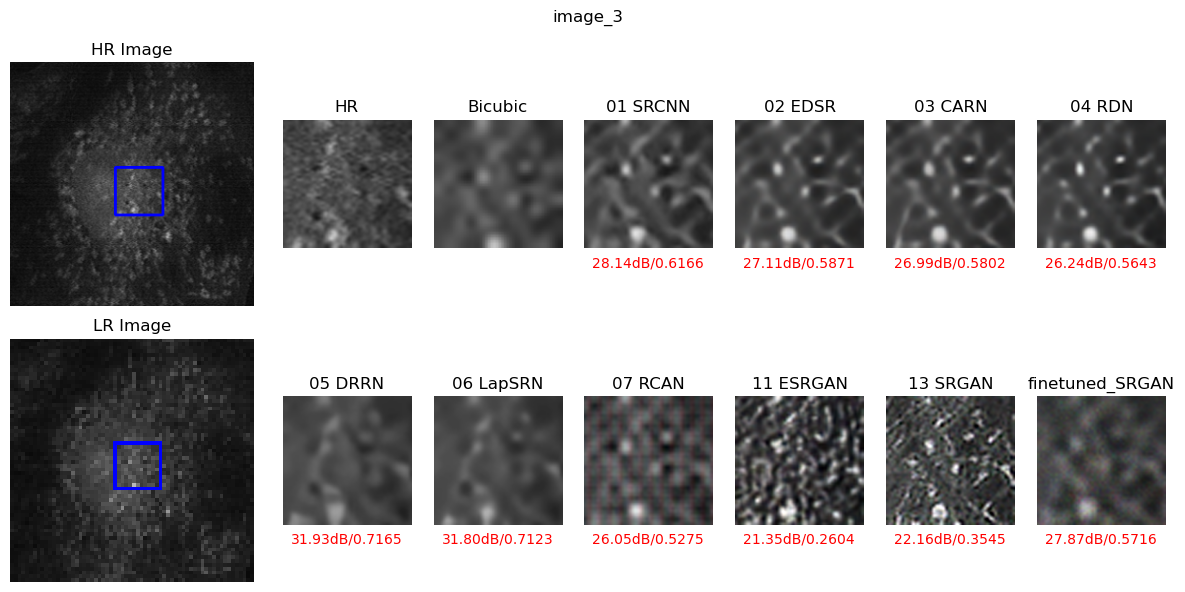

In [191]:
hr_img_rect = hr_img.copy()
lr_img_rect = lr_img.copy()
cv2.rectangle(hr_img_rect, (x, y), (x + w, y + h), (255, 0, 0), 2)
cv2.rectangle(lr_img_rect, (x//4, y//4), (x//4 + w//4, y//4 + h//4), (255, 0, 0), 1)

# Plot the figure
fig, axes = plt.subplots(2, 7, figsize=(12, 6), gridspec_kw={
                         'width_ratios': [2, 1, 1, 1, 1, 1, 1]})  # 2 Rows, 4 Columns

# Place HR image spanning 2x2
axes[0, 0].imshow(cv2.cvtColor(hr_img_rect, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("HR Image")
axes[0, 0].axis("off")
axes[1, 0].set_title("LR Image")
axes[1, 0].imshow(cv2.cvtColor(lr_img_rect, cv2.COLOR_BGR2RGB))
axes[1, 0].axis("off")

# Remove axis labels for merged subplot
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Right Side: Zoomed-in patches from HR, LR, and SR models
for i, (patch, model, psnr, ssim) in enumerate(zip(zoomed_patches, ["HR" , "Bicubic"] + models, [100, 0] + psnr_values, [100, 0] + ssim_values)):
    row, col = divmod(i, 6)  # Arrange in 2 rows of 5 images
    axes[row, col + 1].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    axes[row, col + 1].set_title(model)
    if model == "Bicubic" or model == "HR":
        axes[row, col + 1].axis("off")
        continue
    else:
        axes[row, col + 1].text(12, 210.1, f"{psnr:.2f}dB/{ssim:.4f}", wrap=True, fontsize=10, va='top', color='red')
    axes[row, col + 1].axis("off")

# Adjust layout and save
plt.suptitle(image_name)
plt.tight_layout()
# plt.savefig("SR_zoomed_.png", dpi=300)
plt.show()

In [173]:
for i, (patch, model, psnr) in enumerate(zip(zoomed_patches, ["HR" , "Bicubic"] + models, [100,0] + psnr_values)):
    if model == "Bicubic":
        continue
    else:
        print(f"{model}: PSNR = {psnr:.2f} dB")


HR: PSNR = 100.00 dB
01 SRCNN: PSNR = 28.14 dB
02 EDSR: PSNR = 27.11 dB
03 CARN: PSNR = 26.99 dB
04 RDN: PSNR = 26.24 dB
05 DRRN: PSNR = 31.93 dB
06 LapSRN: PSNR = 31.80 dB
07 RCAN: PSNR = 26.05 dB
11 ESRGAN: PSNR = 21.35 dB
13 SRGAN: PSNR = 22.16 dB
finetuned_SRGAN: PSNR = 27.87 dB


In [32]:
def load_images(model_name, file_names, scale="x4"):
    # hr_path = os.path.join(base_path, f"{model_name}.png")
    # lr_path = os.path.join(base_path, "LR", scale, f"{image_name}.png")

    # hr_img = cv2.imread(f"{hr_path}", cv2.IMREAD_COLOR)
    # lr_img = cv2.imread(f"{lr_path}", cv2.IMREAD_COLOR)

    sr_imgs = []
    for fn in file_names:
        sr_path = os.path.join(base_path, model_name, scale, f"{fn}")
        print(sr_path)
        sr_img = cv2.imread(f"{sr_path}")
        sr_imgs.append(sr_img)

    return sr_imgs

# Define region to zoom in (Modify x, y, w, h based on interest area)


def crop_zoomed_region(img, x, y, w, h, scale_factor=4):
    cropped = img[y:y+h, x:x+w]  # Crop selected area
    zoomed = cv2.resize(cropped, (w*scale_factor, h *
                        scale_factor), interpolation=cv2.INTER_CUBIC)
    return zoomed


def show_crop_area(img, x, y, w, h):
    img_copy = img.copy()
    # x, y, w, h = int(x), int(y), int(w), int(h)
    img_copy = cv2.rectangle(img_copy, (x, y), (x+h, y+w),
                             (255, 0, 0), 2)  # Draw rectangle
    plt.title("Selected Crop Area")
    plt.axis("off")
    plt.imshow(img_copy)

In [ ]:
hr_path = os.path.join(base_path, "srcnn/x2", f"hr.png")
lr_path = os.path.join(base_path, "srcnn/x2", f"lr.png")

hr_img = cv2.imread(f"{hr_path}")
lr_img = cv2.imread(f"{lr_path}")

In [126]:
sr_imgs = load_images('edsr', pp_fn, scale="x4")

for im in sr_imgs:
    print(im.shape)

preprocessing with dl/edsr/x4/lr.png
preprocessing with dl/edsr/x4/base.png
preprocessing with dl/edsr/x4/w.png
preprocessing with dl/edsr/x4/rl.png
preprocessing with dl/edsr/x4/bm.png
preprocessing with dl/edsr/x4/hr.png
(444, 444, 3)
(444, 444, 3)
(444, 444, 3)
(444, 444, 3)
(444, 444, 3)
(444, 444, 3)


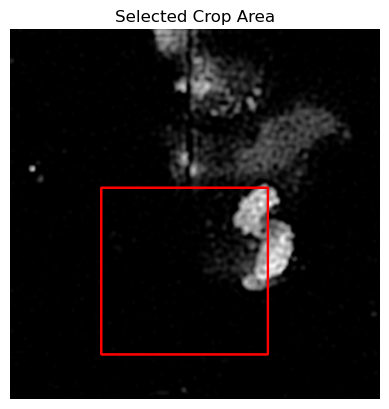

In [127]:
x, y, w, h = 109, 190, 200, 200  # ROI (Region of Interest)
show_crop_area(sr_imgs[3], x, y, w, h)

In [114]:
# Extract zoomed-in patches
# zoomed_patches = [crop_zoomed_region(hr_img, x, y, w, h)]
# zoomed_patches.append(crop_zoomed_region(
#     lr_img, x//4, y//4, w//4, h//4))  # Adjust for LR scale
zoomed_patches = []
for sr_img in sr_imgs:
    zoomed_patches.append(crop_zoomed_region(sr_img, x, y, w, h))

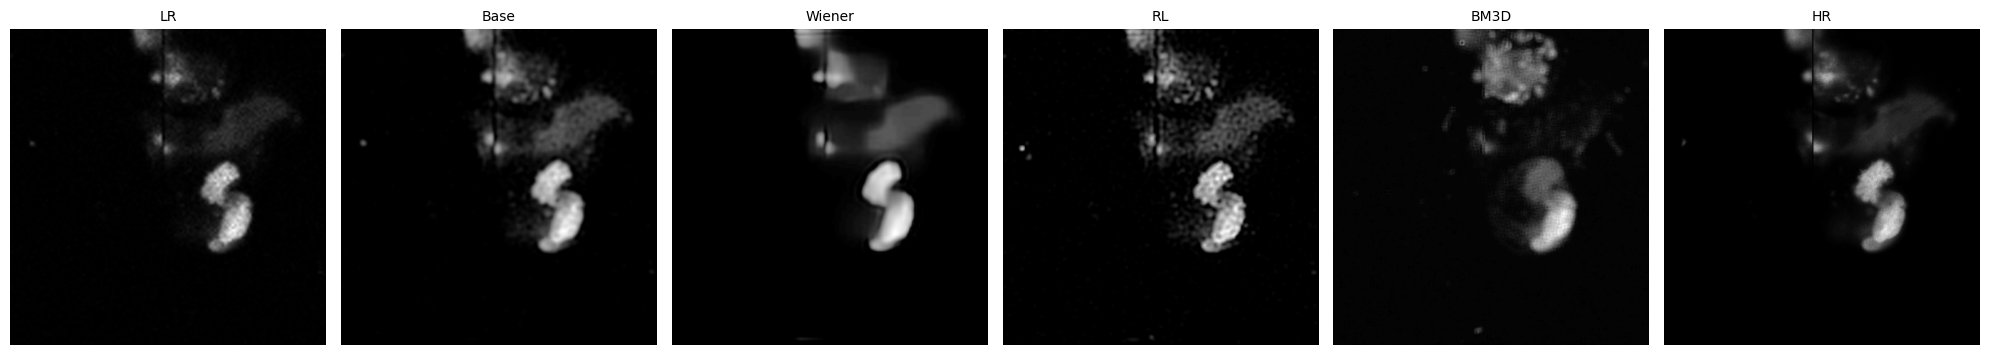

In [128]:
# images = [Image.open(os.path.join(base_path, fname)) for fname in ty]

fig, axs = plt.subplots(1, 6, figsize=(20, 4))
for ax, img, title in zip(axs, sr_imgs, titles_dl):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("preprocessing_with_dl_comparison_grid_edsr_x4.png", dpi=600)
plt.show()